In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.cluster import KMeans

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving customer_support_tickets..csv to customer_support_tickets..csv


In [ ]:
df = pd.read_csv("customer_support_tickets..csv")

In [ ]:
df.head()

,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,operating_system,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment,Resolution_Duration_Days,Priority_Score,Type
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,...,MacOS,Edge,PayPal,French,Afternoon,4.0,Small Business,3.0,4.0,Request
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,...,Windows,Firefox,PayPal,English,Afternoon,2.0,Small Business,13.0,4.0,Problem
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,...,Windows,Safari,Bank Transfer,French,Morning,4.0,Corporate,5.0,2.0,Problem
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,...,Windows,Chrome,Credit Card,Spanish,Afternoon,7.0,Corporate,14.0,2.0,Request
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,...,Linux,Edge,Debit Card,Spanish,Evening,3.0,Corporate,8.0,3.0,Request


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11409 entries, 0 to 11408
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ticket_id                    11409 non-null  int64  
 1   customer_name                11409 non-null  object 
 2   customer_email               11409 non-null  object 
 3   product                      11409 non-null  object 
 4   category                     11409 non-null  object 
 5   issue_description            11409 non-null  object 
 6   resolution_notes             11408 non-null  object 
 7   priority                     11408 non-null  object 
 8   status                       11408 non-null  object 
 9   channel                      11408 non-null  object 
 10  region                       11408 non-null  object 
 11  customer_age                 11408 non-null  float64
 12  customer_gender              11408 non-null  object 
 13  subscription_typ

In [ ]:
df.columns

Index(['ticket_id', 'customer_name', 'customer_email', 'product', 'category',
       'issue_description', 'resolution_notes', 'priority', 'status',
       'channel', 'region', 'customer_age', 'customer_gender',
       'subscription_type', 'customer_tenure_months', 'previous_tickets',
       'customer_satisfaction_score', 'first_response_time_hours',
       'resolution_time_hours', 'ticket_created_date', 'ticket_resolved_date',
       'escalated', 'sla_breached', 'operating_system', 'browser',
       'payment_method', 'language', 'preferred_contact_time',
       'issue_complexity_score', 'customer_segment',
       'Resolution_Duration_Days', 'Priority_Score', 'Type'],
      dtype='object')

In [ ]:
queue_mapping = {

'Technical Issue':'Technical Support',

'Billing Inquiry':'Billing Team',

'Account Management':'Account Team',

'Product Inquiry':'Sales Team',

'Refund Request':'Finance Team',

'Cancellation':'Retention Team'

}

In [ ]:
df['Queue'] = df['category'].map(queue_mapping)

df['Queue'].fillna('General Support', inplace=True)

/tmp/ipykernel_791/1787255357.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Queue'].fillna('General Support', inplace=True)


In [ ]:
df['Queue'] = df['category'].map(queue_mapping)

df['Queue'].fillna('General Support', inplace=True)

/tmp/ipykernel_791/1787255357.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Queue'].fillna('General Support', inplace=True)


In [ ]:
df[['category','Queue']].head()

,category,Queue
0,Account Suspension,General Support
1,Performance Issue,General Support
2,Performance Issue,General Support
3,Subscription Cancellation,General Support
4,Feature Request,General Support


In [ ]:
vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(df['issue_description'])

In [ ]:
similarity_matrix = cosine_similarity(X)

In [ ]:
df['Similarity_Score'] = similarity_matrix.mean(axis=1)

In [ ]:
df[['issue_description','Similarity_Score']].head()

,issue_description,Similarity_Score
0,The payment was deducted from my bank account ...,0.111231
1,I found a bug in the latest update affecting r...,0.098869
2,The application crashes whenever I try to uplo...,0.099571
3,My subscription was cancelled without my reque...,0.116218
4,The system is not syncing data across devices ...,0.093347


In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster_ID'] = kmeans.fit_predict(X)

In [ ]:
cluster_names = {

0:'Account Issues',

1:'Technical Problems',

2:'Payment Issues',

3:'Product Queries',

4:'General Support'

}

df['Cluster_Name'] = df['Cluster_ID'].map(cluster_names)

In [ ]:
df[['Cluster_ID','Cluster_Name']].head()

,Cluster_ID,Cluster_Name
0,1,Technical Problems
1,4,General Support
2,3,Product Queries
3,2,Payment Issues
4,4,General Support


/tmp/ipykernel_791/2443433008.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


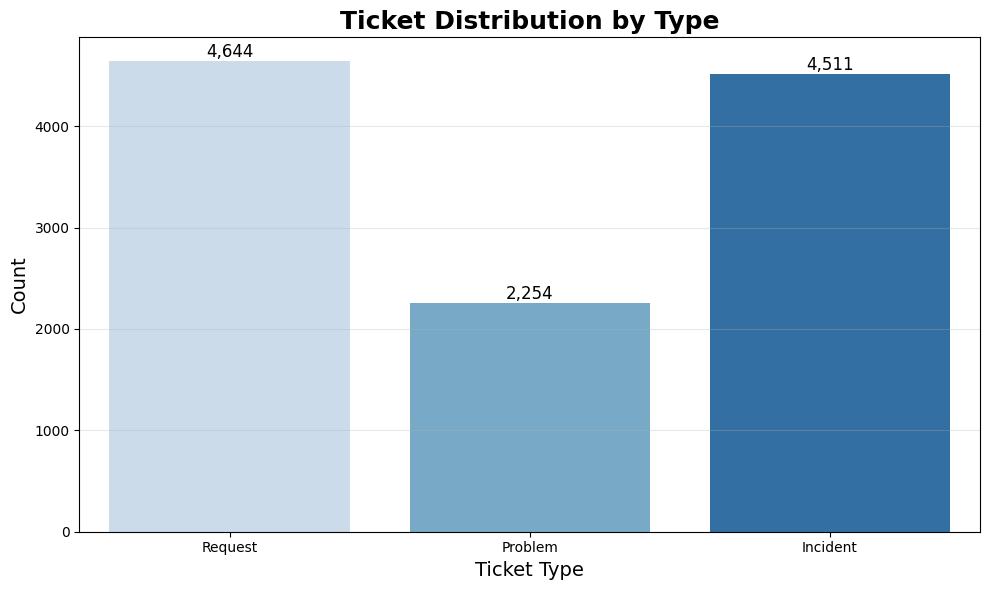

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df,
    x="Type",
    palette="Blues"
)

plt.title("Ticket Distribution by Type", fontsize=18, fontweight='bold')
plt.xlabel("Ticket Type", fontsize=14)
plt.ylabel("Count", fontsize=14)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center',
                va='bottom',
                fontsize=12)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig("plot_ticket_type_distribution.png", dpi=300)

plt.show()

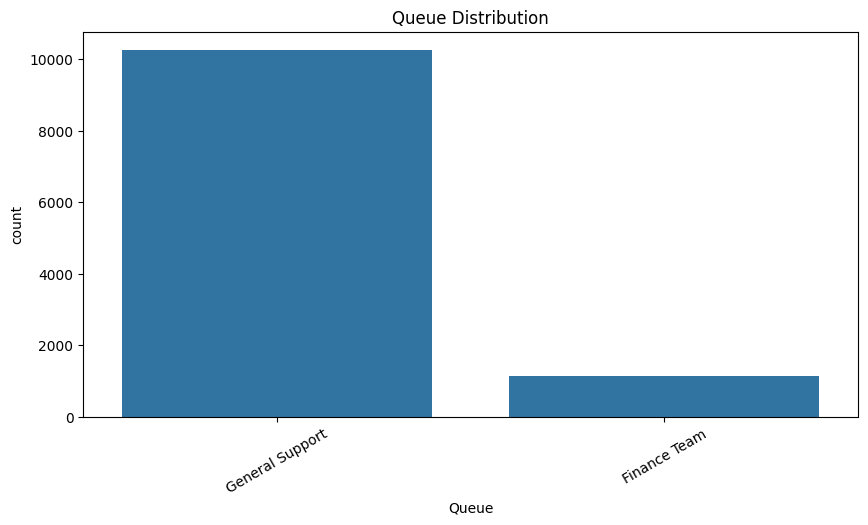

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(data=df,x='Queue')

plt.xticks(rotation=30)

plt.title("Queue Distribution")

plt.show()

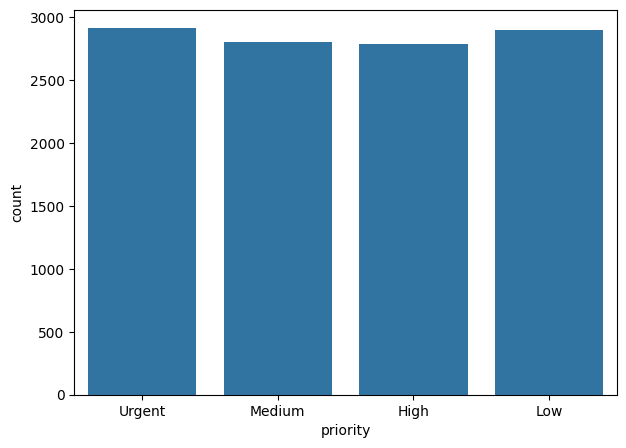

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(data=df,x='priority')

plt.show()

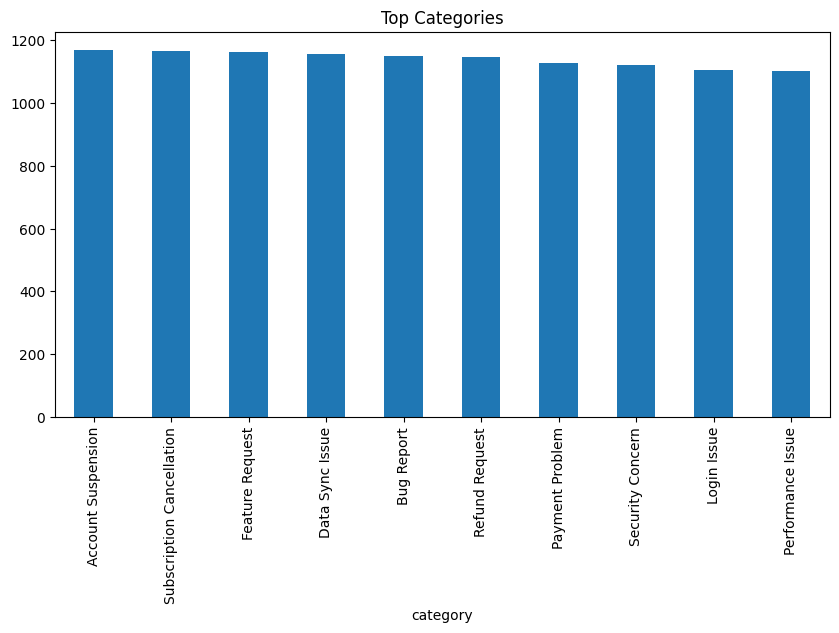

In [ ]:
plt.figure(figsize=(10,5))

df['category'].value_counts().plot(kind='bar')

plt.title("Top Categories")

plt.show()

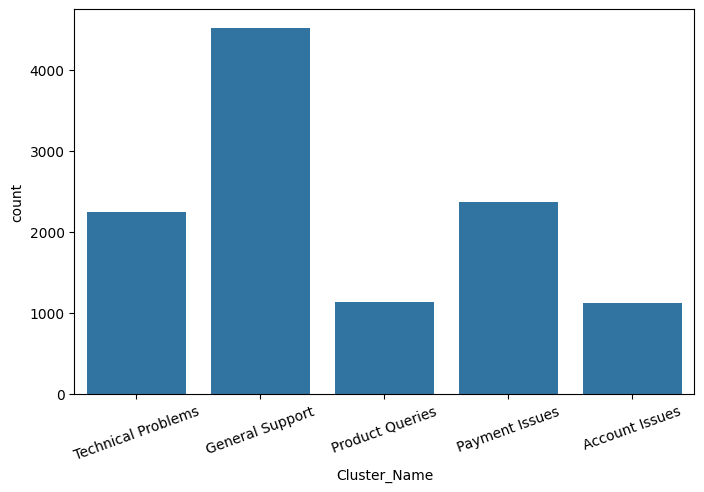

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x='Cluster_Name')

plt.xticks(rotation=20)

plt.show()

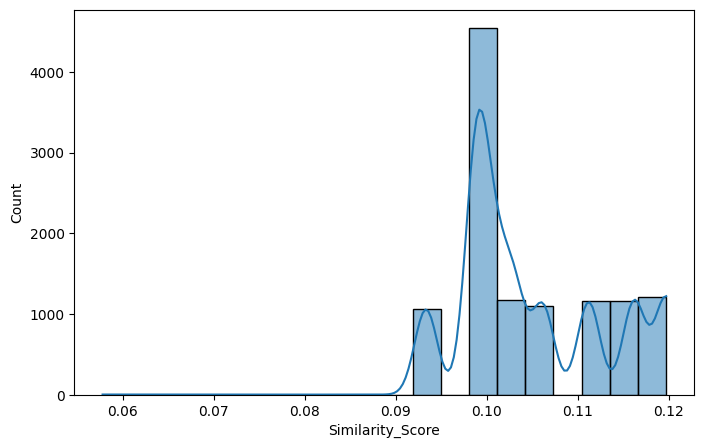

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Similarity_Score'],bins=20,kde=True)

plt.show()

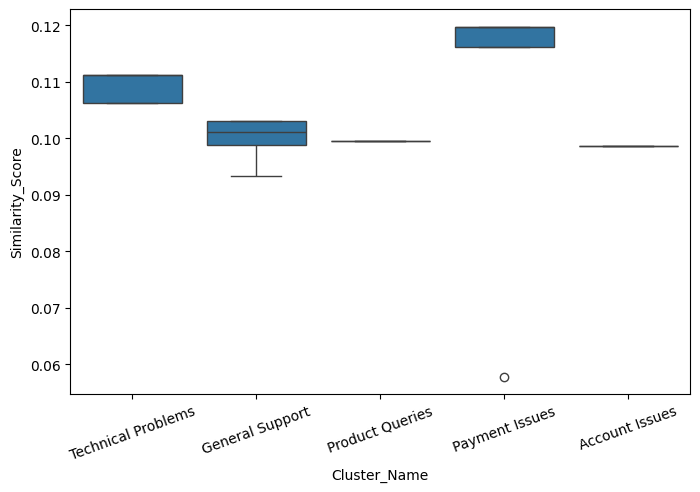

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df,

x='Cluster_Name',

y='Similarity_Score')

plt.xticks(rotation=20)

plt.show()

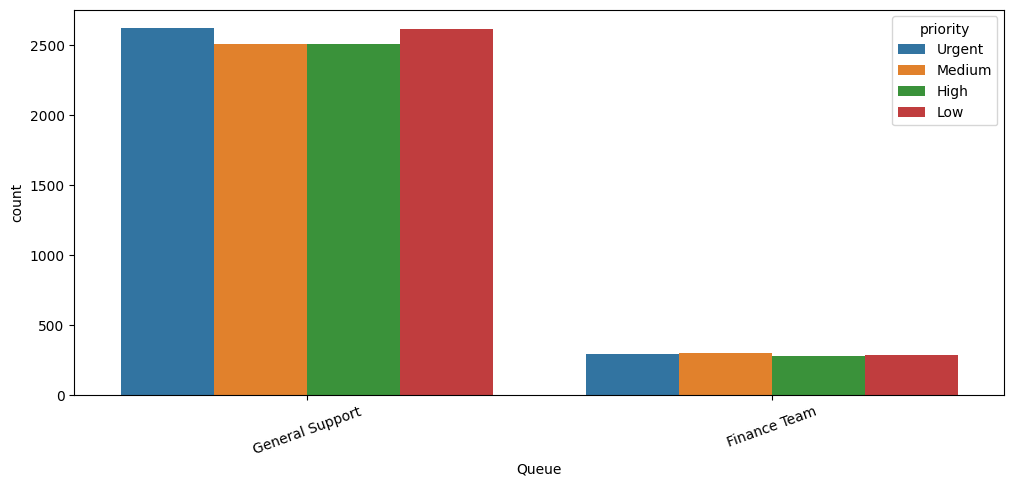

In [ ]:
plt.figure(figsize=(12,5))

sns.countplot(data=df,

x='Queue',

hue='priority')

plt.xticks(rotation=20)

plt.show()

In [ ]:
df.to_csv("Processed_IT_Support_Tickets.csv",index=False)